# Lista 04 - Deteccao de anomalias em logs

Aplicacao do algoritmo Isolation Forest para identificar acessos fora do padrao.


In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

sns.set_theme(style="whitegrid")

Matplotlib is building the font cache; this may take a moment.


In [2]:
# carregar o dataset
df = pd.read_csv("acessos_sistema.csv")
df.insert(0, "id_registro", range(1, len(df) + 1))
df.head()

,id_registro,hora_acesso,duracao_sessao_min,numero_tentativas_login,ip_diferente_habitual,quantidade_paginas_acessadas
0,1,9,35,1,0,12
1,2,10,40,1,0,15
2,3,11,25,1,0,9
3,4,14,50,1,0,18
4,5,15,45,1,0,16


In [3]:
# explorar os dados
print(f"Registros: {len(df)}")
print(f"Valores ausentes: {df.isnull().sum().sum()}")
print(f"Registros duplicados: {df.drop(columns='id_registro').duplicated().sum()}")
df.describe().round(2)

Registros: 80
Valores ausentes: 0
Registros duplicados: 1


,id_registro,hora_acesso,duracao_sessao_min,numero_tentativas_login,ip_diferente_habitual,quantidade_paginas_acessadas
count,80.00,80.00,80.00,80.00,80.0,80.00
mean,40.50,10.35,58.04,3.19,0.5,23.05
std,23.24,7.55,76.11,3.28,0.5,31.66
min,1.00,0.00,1.00,1.00,0.0,1.00
25%,20.75,2.00,4.00,1.00,0.0,2.00
50%,40.50,11.00,35.50,1.00,0.5,13.00
75%,60.25,15.00,52.00,6.00,1.0,18.00
max,80.00,23.00,300.00,10.00,1.0,120.00


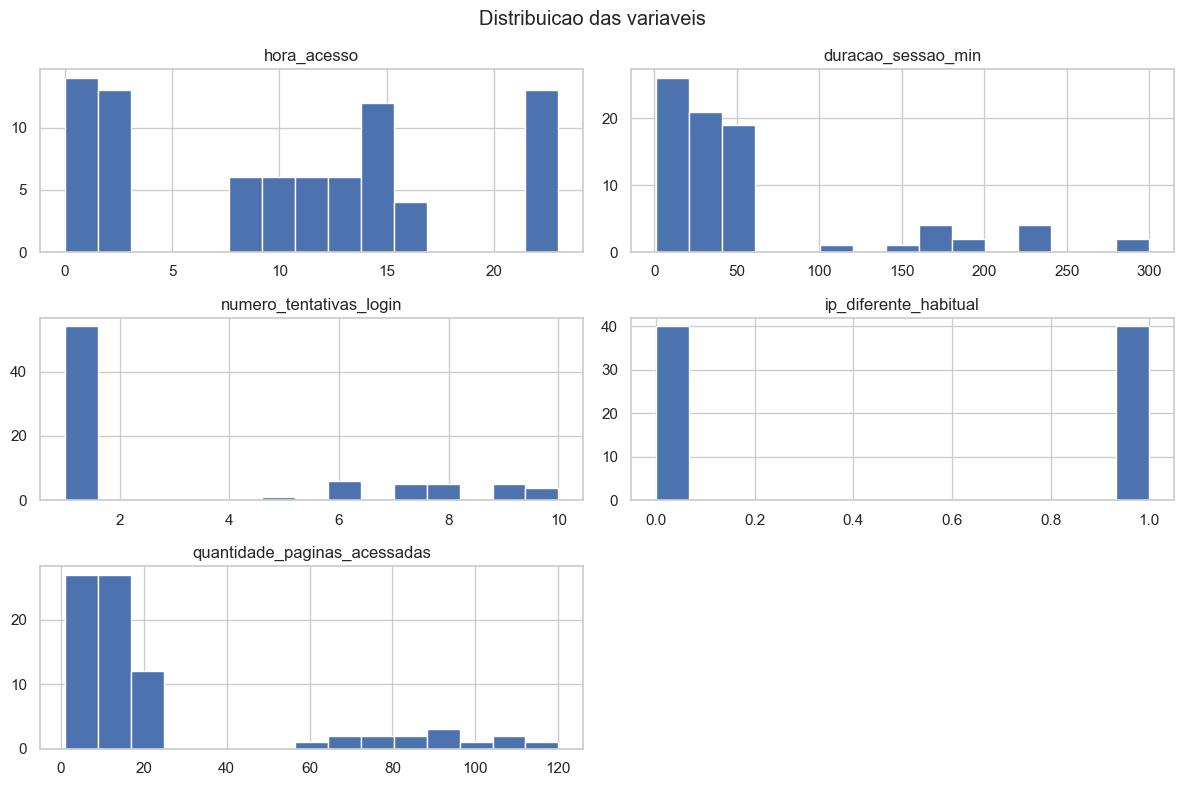

In [4]:
# distribuicao das variaveis
Path("graficos").mkdir(exist_ok=True)
df.drop(columns="id_registro").hist(figsize=(12, 8), bins=15)
plt.suptitle("Distribuicao das variaveis")
plt.tight_layout()
plt.savefig("graficos/distribuicao_variaveis.png", dpi=150)
plt.show()

In [5]:
# selecionar as variaveis usadas pelo modelo
colunas = [
    "hora_acesso",
    "duracao_sessao_min",
    "numero_tentativas_login",
    "ip_diferente_habitual",
    "quantidade_paginas_acessadas"
]
X = df[colunas]

# padronizar os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
# treinar o modelo
model = IsolationForest(
    n_estimators=100,
    contamination=0.10,
    random_state=42
)
model.fit(X_scaled)

,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [7]:
# classificar os acessos: 1 = normal e -1 = anomalia
df["anomalia"] = model.predict(X_scaled)
df["score"] = model.decision_function(X_scaled)
df["classificacao"] = df["anomalia"].map({1: "Normal", -1: "Anomalia"})

df["classificacao"].value_counts()

classificacao
Normal      72
Anomalia     8
Name: count, dtype: int64

In [8]:
# registros classificados como anomalos
anomalias = df[df["anomalia"] == -1].sort_values("score")
anomalias[[
    "id_registro",
    "hora_acesso",
    "duracao_sessao_min",
    "numero_tentativas_login",
    "ip_diferente_habitual",
    "quantidade_paginas_acessadas",
    "score"
]]

,id_registro,hora_acesso,duracao_sessao_min,numero_tentativas_login,ip_diferente_habitual,quantidade_paginas_acessadas,score
71,72,22,300,1,1,120,-0.079061
54,55,23,300,1,1,110,-0.055977
42,43,1,120,1,1,60,-0.049375
75,76,3,240,1,1,110,-0.023733
66,67,23,180,1,1,70,-0.012614
46,47,2,6,9,1,3,-0.007616
51,52,3,150,1,1,65,-0.002800
68,69,2,240,1,1,100,-0.000060


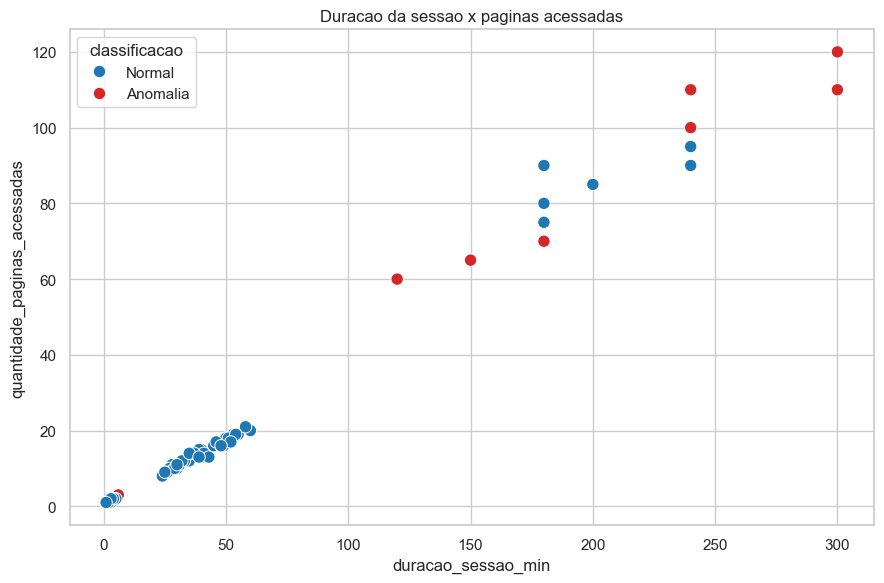

In [9]:
# duracao da sessao x paginas acessadas
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="duracao_sessao_min",
    y="quantidade_paginas_acessadas",
    hue="classificacao",
    palette={"Normal": "#1f77b4", "Anomalia": "#d62728"},
    s=80
)
plt.title("Duracao da sessao x paginas acessadas")
plt.tight_layout()
plt.savefig("graficos/duracao_paginas.png", dpi=150)
plt.show()

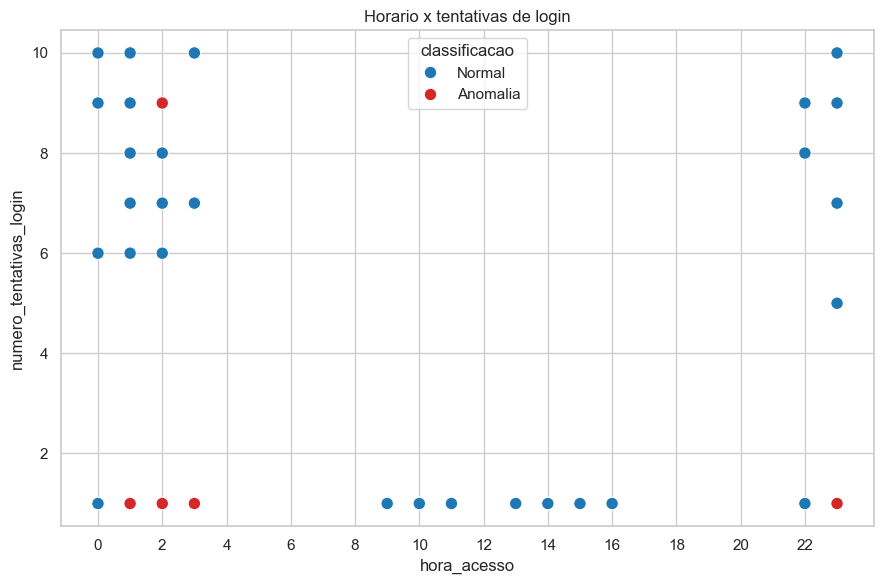

In [10]:
# horario x tentativas de login
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="hora_acesso",
    y="numero_tentativas_login",
    hue="classificacao",
    palette={"Normal": "#1f77b4", "Anomalia": "#d62728"},
    s=80
)
plt.title("Horario x tentativas de login")
plt.xticks(range(0, 24, 2))
plt.tight_layout()
plt.savefig("graficos/hora_tentativas.png", dpi=150)
plt.show()

In [13]:
# salvar os resultados
Path("resultados").mkdir(exist_ok=True)
df.to_csv("resultados/resultado_modelo.csv", index=False)
anomalias.to_csv("resultados/acessos_anomalos.csv", index=False)

## Resumo dos resultados

O modelo classificou 8 dos 80 registros como anomalias. Entre eles aparecem dois perfis principais:

- 7 sessoes noturnas muito longas, com grande quantidade de paginas acessadas;
- 1 sessao noturna curta, com 9 tentativas de login e IP diferente do habitual.

Esses acessos devem ser investigados, mas a classificacao nao confirma um ataque. Viagens, VPN, manutencoes e tarefas administrativas podem produzir comportamentos atipicos legitimos.
